<h1>Tarea 2: Detección de insuficiencia cardiaca</h1>
<p>Jose Luis Romero Vazquez<p>
23/Julio/2023

In [46]:
# ==============================================================================
import pandas as pd
import numpy as np



# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns; sns.set()



# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats
from sklearn.preprocessing import OrdinalEncoder


**Con el repositorio heart.csv que está disponible en el siguiente enlace:**

In [47]:
df = pd.read_csv(r"heart.csv")

**1. Cargue los datos en Python usando Pandas y muestre los primeros 10 registros**

In [136]:
df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ASY,ATA,NAP,TA,Normal,ST,LVH,Up,Flat,Down
0,40,1.0,140,289,0,172,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0.0,160,180,0,156,0.0,1.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1.0,130,283,0,98,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0.0,138,214,0,108,1.0,1.5,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1.0,150,195,0,122,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,39,1.0,120,339,0,170,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6,45,0.0,130,237,0,170,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7,54,1.0,110,208,0,142,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,37,1.0,140,207,0,130,1.0,1.5,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9,48,0.0,120,284,0,120,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


**2. Identifique que porcentaje de valores faltantes tiene cada columna**

In [48]:
df.isna().sum()/len(df)*100

Age               0.0
Sex               0.0
ChestPainType     0.0
RestingBP         0.0
Cholesterol       0.0
FastingBS         0.0
RestingECG        0.0
MaxHR             0.0
ExerciseAngina    0.0
Oldpeak           0.0
ST_Slope          0.0
HeartDisease      0.0
dtype: float64

**3. Muestre los valores estadísticos básicos de todas las columnas (contador, media,
desviación estándar, valor mínimo, valor máximo y los cuartiles)**

In [49]:
media = df.mean()
p90 = df.quantile([0.25, 0.5,0.75])
std1 = df.std(ddof=0)
var1 = df.var(ddof=0)
max1= df.max()
min1= df.min()
na=df.isna()
cont=df.count()

print("media")
print(media)
print("cuartile")
print(p90)
print("desviacion estandar")
print(std1)
print("varianza")
print(var1)
print("Max")
print(max1)
print("Minimo")
print(min1)
print("Contador")
print(cont)

media
Age              53.510893
RestingBP       132.396514
Cholesterol     198.799564
FastingBS         0.233115
MaxHR           136.809368
Oldpeak           0.887364
HeartDisease      0.553377
dtype: float64
cuartile
       Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease
0.25  47.0      120.0       173.25        0.0  120.0      0.0           0.0
0.50  54.0      130.0       223.00        0.0  138.0      0.6           1.0
0.75  60.0      140.0       267.00        0.0  156.0      1.5           1.0
desviacion estandar
Age               9.427478
RestingBP        18.504067
Cholesterol     109.324551
FastingBS         0.422815
MaxHR            25.446463
Oldpeak           1.065989
HeartDisease      0.497143
dtype: float64
varianza
Age                88.877332
RestingBP         342.400511
Cholesterol     11951.857429
FastingBS           0.178773
MaxHR             647.522483
Oldpeak             1.136333
HeartDisease        0.247151
dtype: float64
Max
Age                77


<ipython-input-49-c7723173ac92>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  media = df.mean()
<ipython-input-49-c7723173ac92>:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  p90 = df.quantile([0.25, 0.5,0.75])
<ipython-input-49-c7723173ac92>:3: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  std1 = df.std(ddof=0)
<ipython-input-49-c7723173ac92>:4: Future

**4. Con el siguiente código genere el histograma de todas las columnas:**

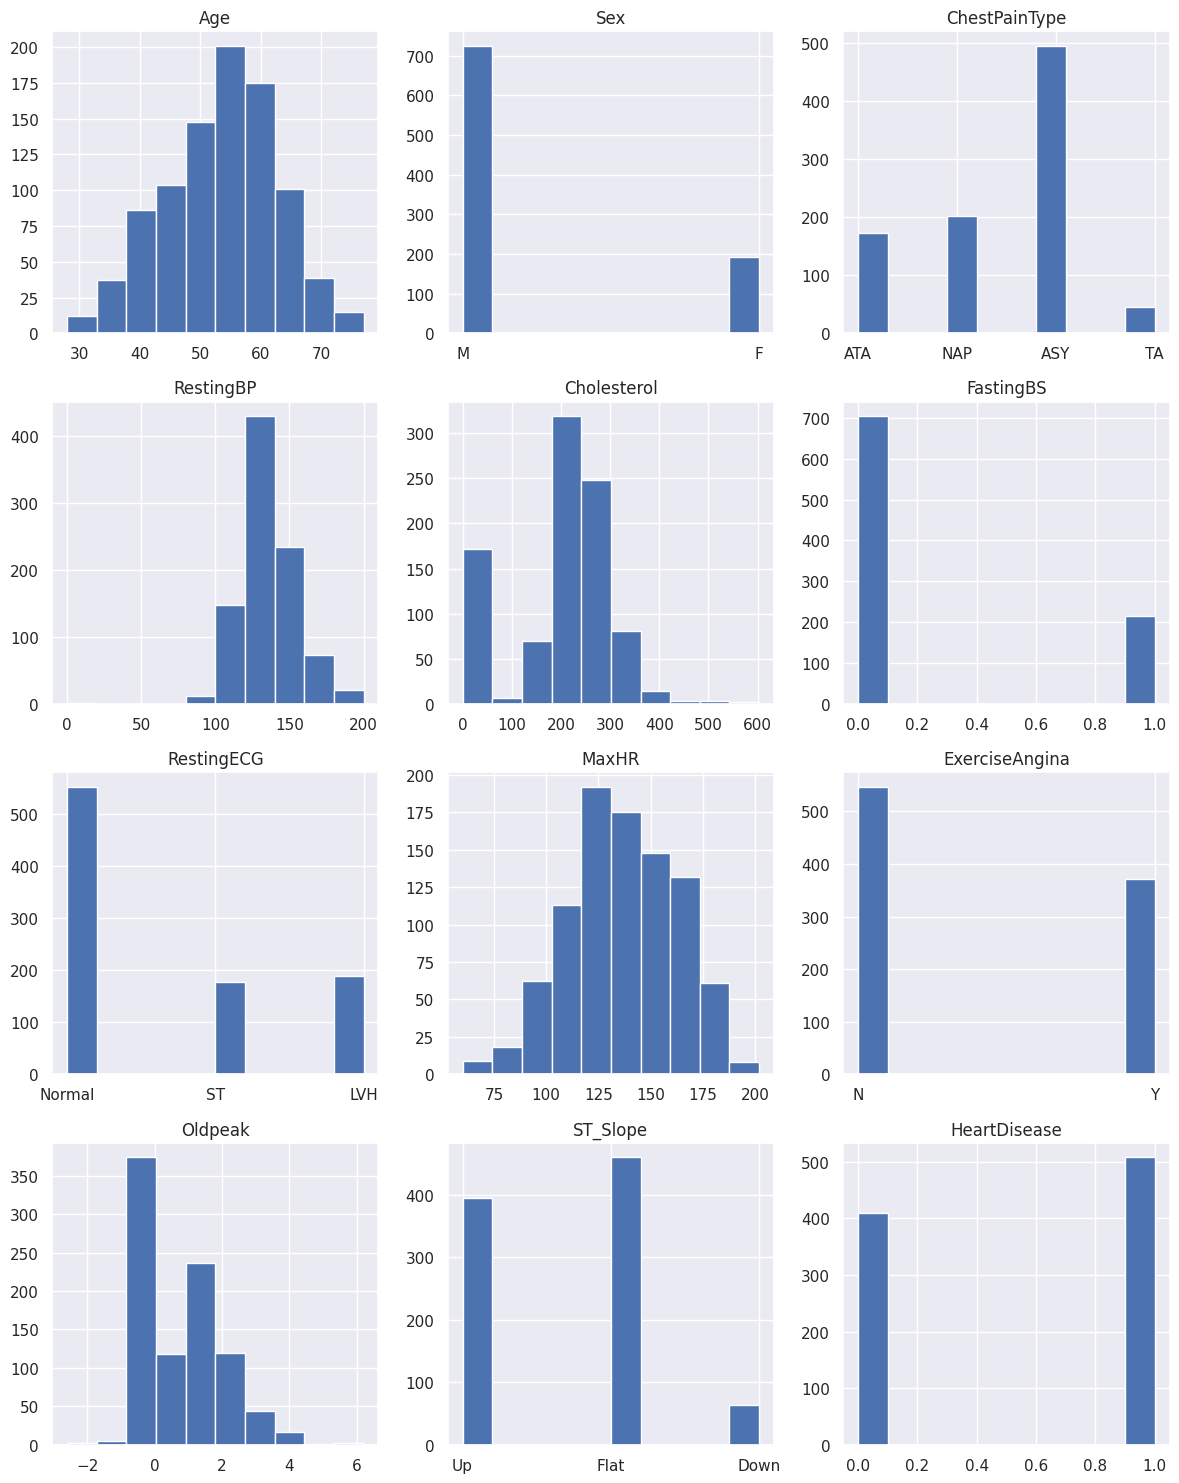

In [50]:
viz_df = df.copy()
k = 0
plt.figure(figsize=(12, 15))
for col in viz_df.columns:
 plt.subplot(4, 3, k + 1)
 plt.hist(viz_df[col])
 plt.title(f"{col}")
 k += 1
plt.tight_layout()

**5. Con el siguiente código genere el diagrama de bigotes de todas las columnas:**

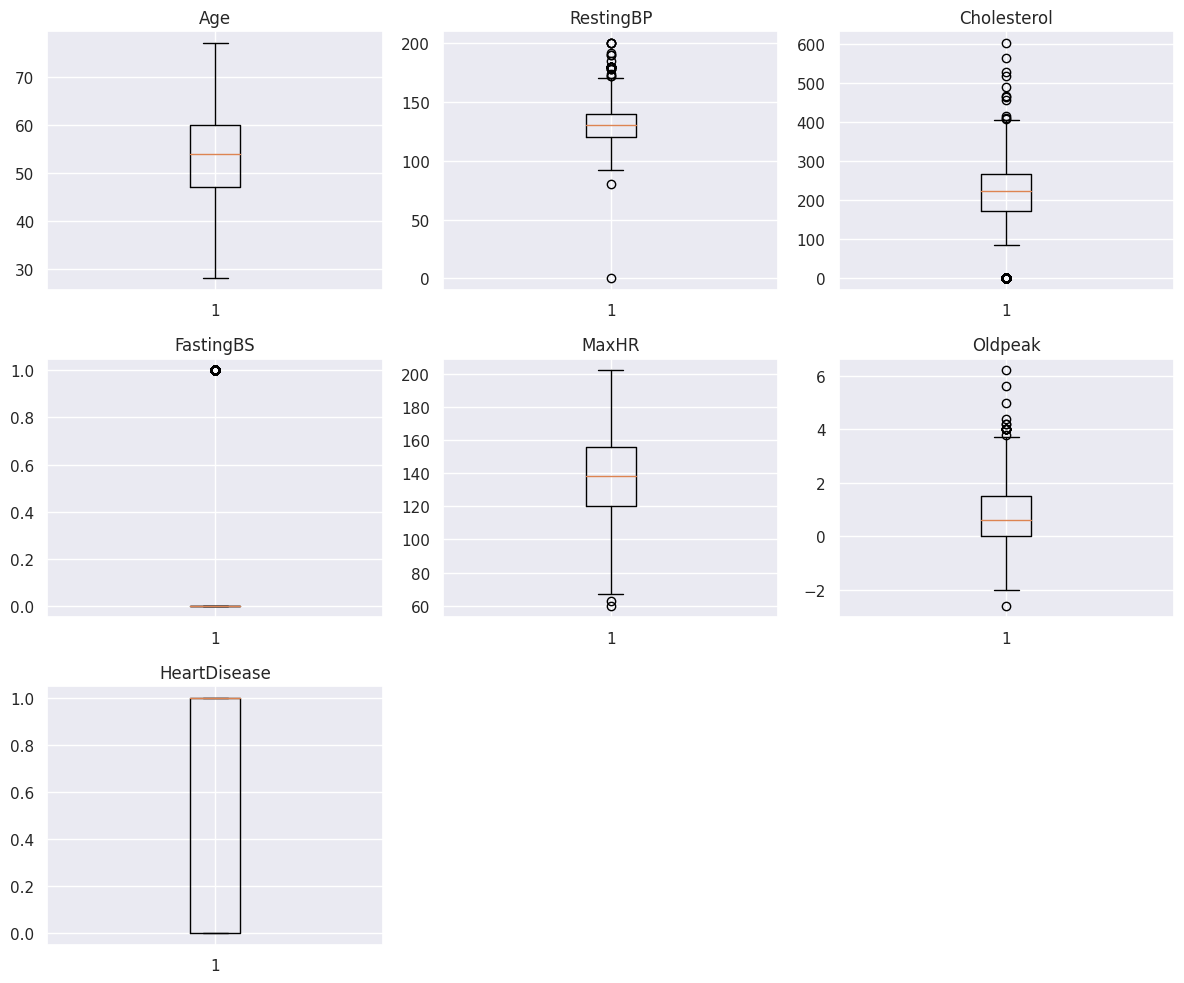

In [51]:
viz_df = df.select_dtypes(include=np.number)
k = 0
plt.figure(figsize=(12, 10))
for col in viz_df.columns:
 plt.subplot(3, 3, k + 1)
 plt.boxplot(viz_df[col])
 plt.title(f"{col}")
 k += 1
plt.tight_layout()


**6. Con el siguiente código obtenga las categorías de las columnas categóricas:**

In [52]:
categoricas=('Sex' ,'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope')
for i in categoricas:
 print("categorias de ",i,":",df[i].unique())


categorias de  Sex : ['M' 'F']
categorias de  ChestPainType : ['ATA' 'NAP' 'ASY' 'TA']
categorias de  RestingECG : ['Normal' 'ST' 'LVH']
categorias de  ExerciseAngina : ['N' 'Y']
categorias de  ST_Slope : ['Up' 'Flat' 'Down']


**7. Como podrá notar sexo y ExerciseAngina solamente poseen 2 posibles valores
convierta estas columnas a numéricas con el OrdinalEncoder.**

In [53]:
encoder = OrdinalEncoder()

df[['Sex','ExerciseAngina']] = encoder.fit_transform(df[['Sex','ExerciseAngina']])

df[['Sex','ExerciseAngina']].head()


,Sex,ExerciseAngina
0,1.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0


**8. Codifique las otras tres columnas categóricas con el OneHotEncoder, asegúrese
de que al indicar el nombre de las columnas resultantes estén en orden alfabético,
pues así las generará el codificador. Una vez codificadas elimínelas del dataframe**

In [54]:
from sklearn.preprocessing import OneHotEncoder
codificador = OneHotEncoder()

codificacion = codificador.fit_transform(df[['ChestPainType']])

nuevas_cols = pd.DataFrame(codificacion.toarray(),

                           columns=codificador.categories_)

nuevas_cols.columns = ['ASY','ATA','NAP','TA']

print(nuevas_cols)

df= pd.concat([df, nuevas_cols], axis="columns")


     ASY  ATA  NAP   TA
0    0.0  1.0  0.0  0.0
1    0.0  0.0  1.0  0.0
2    0.0  1.0  0.0  0.0
3    1.0  0.0  0.0  0.0
4    0.0  0.0  1.0  0.0
..   ...  ...  ...  ...
913  0.0  0.0  0.0  1.0
914  1.0  0.0  0.0  0.0
915  1.0  0.0  0.0  0.0
916  0.0  1.0  0.0  0.0
917  0.0  0.0  1.0  0.0

[918 rows x 4 columns]


In [55]:
codificacion = codificador.fit_transform(df[['RestingECG']])

nuevas_cols = pd.DataFrame(codificacion.toarray(),

                           columns=codificador.categories_)

nuevas_cols.columns = ['Normal', 'ST', 'LVH']

print(nuevas_cols)

df= pd.concat([df, nuevas_cols], axis="columns")

     Normal   ST  LVH
0       0.0  1.0  0.0
1       0.0  1.0  0.0
2       0.0  0.0  1.0
3       0.0  1.0  0.0
4       0.0  1.0  0.0
..      ...  ...  ...
913     0.0  1.0  0.0
914     0.0  1.0  0.0
915     0.0  1.0  0.0
916     1.0  0.0  0.0
917     0.0  1.0  0.0

[918 rows x 3 columns]


In [56]:
codificacion = codificador.fit_transform(df[['ST_Slope']])

nuevas_cols = pd.DataFrame(codificacion.toarray(),

                           columns=codificador.categories_)

nuevas_cols.columns = ['Up', 'Flat', 'Down']

print(nuevas_cols)

df= pd.concat([df, nuevas_cols], axis="columns")

      Up  Flat  Down
0    0.0   0.0   1.0
1    0.0   1.0   0.0
2    0.0   0.0   1.0
3    0.0   1.0   0.0
4    0.0   0.0   1.0
..   ...   ...   ...
913  0.0   1.0   0.0
914  0.0   1.0   0.0
915  0.0   1.0   0.0
916  0.0   1.0   0.0
917  0.0   0.0   1.0

[918 rows x 3 columns]


In [57]:
df.drop(['ChestPainType','RestingECG','ST_Slope'],axis="columns",inplace=True)

In [58]:
df.columns


Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ASY', 'ATA', 'NAP', 'TA',
       'Normal', 'ST', 'LVH', 'Up', 'Flat', 'Down'],
      dtype='object')

**9. Revise las dimensiones del dataframe.**

In [59]:
df.shape

(918, 19)

**10.Genere la matriz de correlación completa y en su forma tidy**

In [60]:
correlation_matrix = df.corr()
correlation_matrix



,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ASY,ATA,NAP,TA,Normal,ST,LVH,Up,Flat,Down
Age,1.000000,0.055750,0.254399,-0.095282,0.198039,-0.382045,0.215793,0.258612,0.282039,0.166607,-0.218165,-0.011335,0.032042,0.145727,-0.230566,0.136798,0.138397,0.185568,-0.258067
Sex,0.055750,1.000000,0.005133,-0.200092,0.120076,-0.189186,0.190664,0.105734,0.305445,0.183876,-0.161522,-0.066486,-0.004031,-0.049518,-0.010634,0.063715,0.066036,0.116077,-0.150942
RestingBP,0.254399,0.005133,1.000000,0.100893,0.070193,-0.112135,0.155101,0.164803,0.107589,0.048824,-0.046153,-0.041348,0.049855,0.053166,-0.116851,0.090447,-0.007912,0.099207,-0.096146
Cholesterol,-0.095282,-0.200092,0.100893,1.000000,-0.260974,0.235792,-0.034166,0.050148,-0.232741,-0.120531,0.150954,-0.006634,0.017365,0.177077,-0.038470,-0.133106,-0.083371,-0.050953,0.094027
FastingBS,0.198039,0.120076,0.070193,-0.260974,1.000000,-0.131438,0.060451,0.052698,0.267291,0.131176,-0.140514,-0.039249,0.026885,-0.011656,-0.093028,0.127110,0.105102,0.107006,-0.161730
MaxHR,-0.382045,-0.189186,-0.112135,0.235792,-0.131438,1.000000,-0.370425,-0.160691,-0.400421,-0.354963,0.253735,0.134580,0.100025,0.125793,0.023801,-0.157879,-0.073316,-0.342581,0.383397
ExerciseAngina,0.215793,0.190664,0.155101,-0.034166,0.060451,-0.370425,1.000000,0.408752,0.494282,0.430034,-0.300365,-0.166030,-0.128105,-0.016382,-0.072924,0.107036,0.136439,0.382237,-0.455676
Oldpeak,0.258612,0.105734,0.164803,0.050148,0.052698,-0.160691,0.408752,1.000000,0.403951,0.280026,-0.262124,-0.106212,0.032231,0.086794,-0.116719,0.055958,0.322130,0.283295,-0.450577
HeartDisease,0.282039,0.305445,0.107589,-0.232741,0.267291,-0.400421,0.494282,0.403951,1.000000,0.516716,-0.401924,-0.212964,-0.054790,0.010670,-0.091580,0.102527,0.122527,0.554134,-0.622164
ASY,0.166607,0.183876,0.048824,-0.120531,0.131176,-0.354963,0.430034,0.280026,0.516716,1.000000,-0.522432,-0.577670,-0.249003,0.002289,-0.063606,0.076438,0.103407,0.303645,-0.359443


**11.Separe las columnas independientes de la variable objetivo ('HeartDisease') en
X,Y**

In [61]:
import tarfile
import urllib



import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, r2_score, mean_squared_error, classification_report, mean_absolute_error
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

import sklearn

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
from math import sqrt

In [62]:
X = df.drop("HeartDisease", axis=1)
Y = df["HeartDisease"]



**12.Use la función train_test_split para separar el conjunto de datos en 80%
entrenamiento y 20% prueba.**

In [63]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=12345)

**13.Escale los datos (solo Xtest y Xtrain)**

In [64]:
scaler_minmax=MinMaxScaler()
Xtrain= scaler_minmax.fit_transform(Xtrain)
Xtrain[:5, :7]

array([[0.46938776, 0.        , 0.8       , 0.53723404, 0.        ,
        0.63380282, 1.        ],
       [0.46938776, 1.        , 0.7       , 0.        , 0.        ,
        0.        , 0.        ],
       [0.6122449 , 1.        , 0.73      , 0.38652482, 0.        ,
        0.31690141, 0.        ],
       [0.65306122, 1.        , 0.65      , 0.36524823, 0.        ,
        0.50704225, 1.        ],
       [0.73469388, 1.        , 0.715     , 0.54255319, 1.        ,
        0.38732394, 1.        ]])

In [65]:

Xtest= scaler_minmax.fit_transform(Xtest)
Xtest[:5, :7]

array([[0.51111111, 1.        , 0.28421053, 0.47429519, 0.        ,
        0.32380952, 1.        ],
       [0.55555556, 1.        , 0.32631579, 0.27529022, 0.        ,
        0.55238095, 0.        ],
       [0.86666667, 1.        , 0.64210526, 0.40630182, 0.        ,
        0.58095238, 0.        ],
       [0.48888889, 1.        , 0.47368421, 0.33665008, 1.        ,
        0.6952381 , 1.        ],
       [0.57777778, 1.        , 0.57894737, 0.20895522, 1.        ,
        0.86666667, 0.        ]])

**14.Haga el análisis de componentes principales con 18 componentes y vea que
porcentaje de varianza explican los primeros 12 componentes. Repita el análisis,
pero ahora con usando solo 12.**

**15. Obtenga los componentes principales del conjunto X (train y test).**

In [66]:
pca=PCA(n_components=12) # del ejercicio de PCA
pca.fit(Xtrain) # obtener los componentes principales
Xtrain_pca=pca.transform(Xtrain) # convertimos nuestros datos con las nuevas dimensiones de PCA

print("shape of X_pca", Xtrain_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:4]))

shape of X_pca (734, 12)
[0.27966854 0.14718446 0.1185686  0.08650736 0.07947648 0.07114823
 0.06027564 0.05660725 0.03575205 0.02285188 0.01561092 0.01251368]
suma: 0.6319289604799201


In [67]:

Xtest_pca=pca.transform(Xtest) # convertimos nuestros datos con las nuevas dimensiones de PCA

print("shape of X_pca", Xtest_pca.shape)
exp2 = pca.explained_variance_ratio_
print(exp2)
print('suma:',sum(exp2[0:4]))

shape of X_pca (184, 12)
[0.27966854 0.14718446 0.1185686  0.08650736 0.07947648 0.07114823
 0.06027564 0.05660725 0.03575205 0.02285188 0.01561092 0.01251368]
suma: 0.6319289604799201


**16.Genere un GridSearchCV para encontrar la mejor configuración
(gridsearch.best_params_) para el KNeighborsClassifier usando los siguientes
parámetros:
parameters = {"n_neighbors": range(2, 50),"weights":('distance','uniform')}**

In [123]:
from sklearn.model_selection import GridSearchCV
parameters = {"n_neighbors": range(2, 50),"weights":('distance','uniform')}
gridsearch = GridSearchCV(KNeighborsClassifier(), parameters)
gridsearch.fit(Xtrain_pca, Ytrain)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(2, 50),
                         'weights': ('distance', 'uniform')})

**17.Entrene el modelo GridSearchCV, haga las predicciones y obtenga el error
cuadrático medio para los datos de prueba y los de entrenamiento**

In [124]:
gridsearch.best_params_

{'n_neighbors': 47, 'weights': 'uniform'}

In [126]:
train_preds_grid = gridsearch.predict(Xtrain_pca)
train_mse = mean_squared_error(Ytrain, train_preds_grid)
train_rmse = sqrt(train_mse)
test_preds_grid = gridsearch.predict(Xtest_pca)
test_mse = mean_squared_error(Ytest, test_preds_grid)
test_rmse = sqrt(test_mse)
print("train: ",train_rmse)
print("test: ",test_rmse)

train:  0.3727795295569162
test:  0.4104610345325914


**18.Muestre la matriz de confusión, el puntaje F1 y el reporte de clasificación de los
datos de prueba.**

In [111]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
modelo=KNeighborsClassifier(n_neighbors=47)

In [127]:
modelo.fit(Xtrain_pca,Ytrain)
y_pred= modelo.predict(Xtest_pca)
print(classification_report(Ytest,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        87
           1       0.82      0.89      0.85        97

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.84       184
weighted avg       0.84      0.84      0.84       184



In [128]:
test_mse = mean_squared_error(Ytest, y_pred)
test_rmse = sqrt(test_mse)
print("test: ",test_rmse)

test:  0.4037864265436241


In [129]:
print('CONFUSION MATRIX:\n', confusion_matrix(Ytest,y_pred))

CONFUSION MATRIX:
 [[68 19]
 [11 86]]


In [130]:
68/(68+19)

0.7816091954022989

In [131]:
h=BaggingClassifier(KNeighborsClassifier(n_neighbors=46),max_samples=0.7,max_features=0.7,n_estimators=1000)

In [132]:
h.fit(Xtrain_pca,Ytrain)
y_pred=h.predict(Xtest_pca)
print(classification_report(Ytest,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82        87
           1       0.81      0.92      0.86        97

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.84      0.84       184



In [133]:
test_mse = mean_squared_error(Ytest, y_pred)
test_rmse = sqrt(test_mse)
print("test: ",test_rmse)

test:  0.39699961669021033


In [134]:
print('CONFUSION MATRIX:\n', confusion_matrix(Ytest,y_pred))

CONFUSION MATRIX:
 [[66 21]
 [ 8 89]]


**19.Usando 2 de los componentes principales grafique los datos reales y las
predicciones del modelo para identificar visualmente que tan efectivo es el modelo.**

<ipython-input-135-4716da65992d>:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(
<ipython-input-135-4716da65992d>:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(


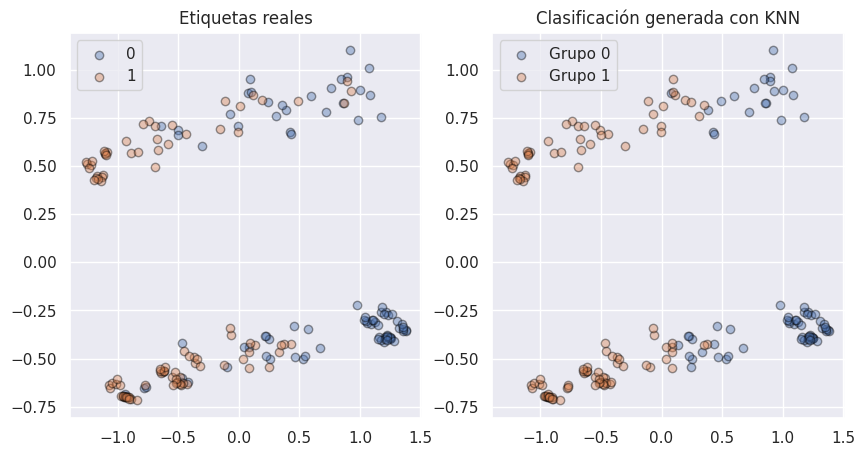

In [135]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(Ytest):
    ax[0].scatter(
        x = Xtest_pca[Ytest == i, 0],
        y = Xtest_pca[Ytest == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= i,
        alpha=0.4
    )
ax[0].set_title('Etiquetas reales')
ax[0].legend();

for i in np.unique(y_pred):
    ax[1].scatter(
        x = Xtest_pca[y_pred == i, 0],
        y = Xtest_pca[y_pred == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}",
        alpha=0.4
    )

ax[1].set_title('Clasificación generada con KNN')
ax[1].legend();